In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

import sys, os
# This is not super pretty, but I think this is the best way to import stuff from ../../../util?
CODE_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if CODE_ROOT not in sys.path:
    sys.path.insert(1, CODE_ROOT)

from util.spectra_helpers import SpectraCustomHDF5
from util.sim_data_helpers import get_cosmo_parameters

In [2]:
def build_dataset_for_gridpoints(gridpoints, suite_to_use, suite_of_spectra):
    """Collects the Flux data from the gridpoint spectra files and returns them as X and y data np.arrays

    Args:
        gridpoints (list): list with the grid point numbers to use
        suite_to_use (string): simulation suite to use

    Returns:
        np.array(X): Array of spectra (flux values)
        np.array(y): Array of cosmo parameters (for each spectrum)
    """
    X, y = [], []

    for i in gridpoints:
        path_to_file = f"/vera/ptmp/gc/jerbo/training_data/{suite_of_spectra}/gp{i}_spectra.hdf5"
        spec_file = SpectraCustomHDF5(path_to_file)
        _, flux = spec_file.get_all_spectra()  
        flux = flux[:1000]  # (1000, 468) TODO: delete this line for training with the full dataset

        params = get_cosmo_parameters(
            f"/vera/ptmp/gc/jerbo/{suite_to_use}/gridpoint{i}/"
        )

        for spec in flux:
            X.append(spec)
            y.append(params)

    return np.array(X), np.array(y)


class SpectraCosmoDataset(Dataset):
    """Class that defines a custom dataset for the spectra data
    """
    def __init__(self, X, y, dtype=torch.float32):
        self.X = torch.tensor(X, dtype=dtype)
        self.y = torch.tensor(y, dtype=dtype)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

def _normalize(dataset, X_mean, X_std, y_mean, y_std):
    """Normalize the given dataset using the other given parameters

    Args:
        dataset (torch.utils.data.Dataset): dataset to be normalized
        X_mean (float): mean of the training X data
        X_std (_type_): std of the training X data
        y_mean (_type_): mean of the training y data
        y_std (_type_): std of the training y data
    """
    dataset.X = (dataset.X - X_mean) / X_std
    dataset.y = (dataset.y - y_mean) / y_std


def get_datasets(suite_to_use, suite_of_spectra, log_file_path):
    """Split the gridpoints into training, test and eval and then collect the datasets and normalize them

    Args:
        suite_to_use (string): simulation suite to use
        log_file_path (string): path to the log file

    Returns:
        train_dataset (SpectraCosmoDataset): training dataset
        test_dataset (SpectraCosmoDataset): test dataset
        eval_dataset (SpectraCosmoDataset): evaluation dataset
    """

    ################# Make random list of gridpoints for train, eval and test sets #################
    index_list = np.array(list(range(50)))
    np.random.seed(42)
    np.random.shuffle(index_list)

    n_train = int(0.7 * len(index_list))
    n_eval  = int(0.15 * len(index_list))

    train_gps = index_list[:n_train]
    eval_gps  = index_list[n_train:n_train + n_eval]
    test_gps  = index_list[n_train + n_eval:]

    ################ Make the datasets #####################

    X_train, y_train = build_dataset_for_gridpoints(train_gps, suite_to_use, suite_of_spectra)
    X_eval,  y_eval  = build_dataset_for_gridpoints(eval_gps,  suite_to_use, suite_of_spectra)
    X_test,  y_test  = build_dataset_for_gridpoints(test_gps,  suite_to_use, suite_of_spectra)

    train_dataset = SpectraCosmoDataset(X_train, y_train)
    eval_dataset  = SpectraCosmoDataset(X_eval,  y_eval)
    test_dataset  = SpectraCosmoDataset(X_test,  y_test)

    ############### Standardize the data ####################

    X_mean = train_dataset.X.mean(dim=0)
    X_std  = train_dataset.X.std(dim=0) + 1e-8

    y_mean = train_dataset.y.mean(dim=0)
    y_std  = train_dataset.y.std(dim=0) + 1e-8

    _normalize(train_dataset, X_mean, X_std, y_mean, y_std)
    _normalize(eval_dataset, X_mean, X_std, y_mean, y_std)
    _normalize(test_dataset, X_mean, X_std, y_mean, y_std)

    ############## Test if there is no information leakege between datasets ##############

    train_cosmo = set(map(tuple, y_train))
    test_cosmo  = set(map(tuple, y_test))

    assert train_cosmo.isdisjoint(test_cosmo)

    return train_dataset, test_dataset, eval_dataset


def get_datasets_shuffle_over_gps(suite_to_use, suite_of_spectra, log_file_path):

    gps_list = [i for i in range(50)]

    X_all, y_all = build_dataset_for_gridpoints(gps_list, suite_to_use, suite_of_spectra)

    print(X_all.shape[0])

    index_list = np.array(list(range(X_all.shape[0])))
    np.random.seed(42)
    np.random.shuffle(index_list)

    X_all = X_all[index_list]
    y_all = y_all[index_list]

    n_train = int(0.7 * X_all.shape[0])
    n_eval  = int(0.15 * X_all.shape[0])

    print(n_train, n_eval)

    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_eval,  y_eval = X_all[n_train:n_eval+n_train], y_all[n_train:n_eval+n_train]
    X_test,  y_test = X_all[n_eval+n_train:], y_all[n_eval+n_train:]

    train_dataset = SpectraCosmoDataset(X_train, y_train)
    eval_dataset  = SpectraCosmoDataset(X_eval,  y_eval)
    test_dataset  = SpectraCosmoDataset(X_test,  y_test)

    return train_dataset, eval_dataset, test_dataset



In [3]:
train_dataset, eval_dataset, test_dataset = get_datasets_shuffle_over_gps("L25n256_suite", "L25n256_suite_no_noise", "")

50000
35000 7500


In [4]:
print(test_dataset.X.shape)

torch.Size([7500, 464])


In [8]:
def build_dataset_for_gridpoints(gridpoints, suite_to_use, suite_of_spectra):
    """Collects the Flux data from the gridpoint spectra files and returns them as X and y data np.arrays

    Args:
        gridpoints (list): list with the grid point numbers to use
        suite_to_use (string): simulation suite to use

    Returns:
        np.array(X): Array of spectra (flux values)
        np.array(y): Array of cosmo parameters (for each spectrum)
    """
    X, y = [], []

    for i in gridpoints:
        path_to_file = f"/vera/ptmp/gc/jerbo/training_data/{suite_of_spectra}/gp{i}_spectra.hdf5"
        spec_file = SpectraCustomHDF5(path_to_file)
        _, flux = spec_file.get_all_spectra()  
        flux = flux[:1000]  # (1000, 468) TODO: delete this line for training with the full dataset

        metadata = spec_file.get_header()
        params = metadata["Omega0"], metadata["OmegaBaryon"], metadata["OmegaLambda"], metadata["HubbleParam"]

        for spec in flux:
            X.append(spec)
            y.append(params)

    return np.array(X), np.array(y)

build_dataset_for_gridpoints([0, 1], "L25n256_suite", "L25n256_suite_snr_10")

(array([[0.77365594, 0.73767347, 1.06907492, ..., 0.62179574, 0.62151389,
         0.63580617],
        [0.6653029 , 0.92472926, 0.7233436 , ..., 0.9055679 , 0.71457262,
         0.79137059],
        [0.28843209, 0.22627541, 0.50724013, ..., 0.86083002, 0.87083678,
         0.78957716],
        ...,
        [1.04591265, 0.97184192, 0.92137722, ..., 0.92894366, 1.01547362,
         1.16185885],
        [0.91718743, 0.92365225, 0.9604053 , ..., 0.92081285, 0.9527758 ,
         1.06267218],
        [1.07069345, 1.14991821, 0.92941836, ..., 0.90432288, 0.92403742,
         1.15964486]]),
 array([[0.4798, 0.0953, 0.5202, 0.5689],
        [0.4798, 0.0953, 0.5202, 0.5689],
        [0.4798, 0.0953, 0.5202, 0.5689],
        ...,
        [0.3812, 0.005 , 0.6188, 0.5747],
        [0.3812, 0.005 , 0.6188, 0.5747],
        [0.3812, 0.005 , 0.6188, 0.5747]]))

In [7]:
import matplotlib.pyplot as plt
import math
import numpy as np

In [8]:
(np.random.random(1000)*300 + 50).min()

50.25965168912606

In [9]:
gp_paths = [f"/vera/ptmp/gc/jerbo/L25n256_suite/gridpoint{i}/" for i in range(50)]

params = []
for path in gp_paths:
    params.append(get_cosmo_parameters(path))

print(len(params))

50


In [10]:
mock_spec_len = 464

gauss_pars = []

for (Om, Ob, OL, H) in params:
    width = (Om - 0.1) /  0.4  # scale to 0 to 1
    depth = (Ob - 0.001) / 0.1  # scale to 0 to 1
    pos = (H - 0.55) / 0.3  # scale to 0 to 1

    gauss_pars.append([width, depth, pos])


In [11]:
mock_spec_len = 464

gauss_pars = []

for i in range(100):
    width = np.random.random(1)[0]
    depth = np.random.random(1)[0]
    pos = np.random.random(1)[0]

    gauss_pars.append([width, depth, pos])

In [12]:
def gauss(mu, sigma, depth, leng):
    x = np.array([i for i in range(leng)])
    return depth * np.exp(-(x - mu)**2 / (2*sigma**2))

path = "/vera/ptmp/gc/jerbo/training_data/mock_gauss_finedistr_suite/"

#for gp, (Om, Ob, OL, H) in enumerate(params):
for i in range(100):

    out_path = path + f"gp{i}_spectra.hdf5"

    width = np.random.random(1)[0]
    depth = np.random.random(1)[0]
    pos = np.random.random(1)[0]

    """
    width = (Om - 0.1) /  0.4  # scale to 0 to 1
    depth = (Ob - 0.001) / 0.1  # scale to 0 to 1
    pos = (H - 0.55) / 0.3  # scale to 0 to 1
    """

    sigma = width * mock_spec_len/10
    a = depth / 1.8
    seperation = pos * 300
    mu = np.random.random(1000)*(mock_spec_len - (pos * 300))

    mock_specs = []
    
    for m in mu:
        mock_spec = np.zeros(mock_spec_len) + 1

        dip_1 = gauss(m, sigma, a, mock_spec_len)
        dip_2 = gauss(m + seperation, sigma, a, mock_spec_len)

        mock_spec = mock_spec - dip_1 - dip_2

        mock_specs.append(mock_spec)  # for gaussian dip spectra
        # mock_specs.append(np.random.random(mock_spec_len)+0.5)  # for fully random noise spectra

    metadata_file = {
        "Omega0": width,
        "OmegaLambda": 1 - width,
        "OmegaBaryon": depth,
        "HubbleParam": pos,
        "BoxSize": 999,
        "Redshift": 999,
        "SNR": 999,
        "Noise_random_distr": ""
    }

    mock_specs = np.array(mock_specs)
    mock_wavelengths = np.zeros(mock_spec_len) + 1

    spec_file = SpectraCustomHDF5(out_path)
    spec_file.create_file(metadata_file, mock_wavelengths, mock_specs)



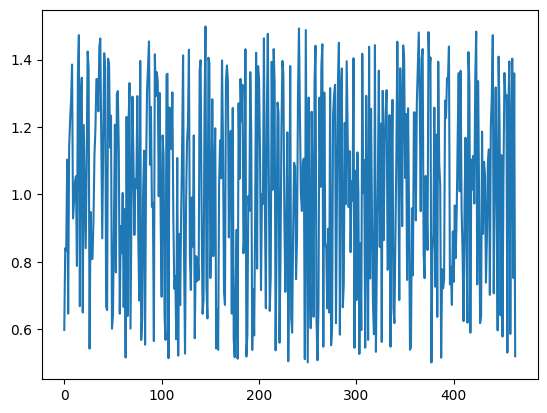

In [19]:
plot_spec = mock_specs[10]

plt.plot([i for i in range(len(plot_spec))], plot_spec)
plt.show()

In [ ]:
mock_spec_noise = np.random.random(mock_spec_len)+0.5

In [ ]:
import os


def get_2nd_try_helper(base_path):
    files = os.listdir(base_path)
    sp_paths = [base_path + i for i in files]
    print(sp_paths)

    X, y = [], []
    for this_file in sp_paths:
        spec_file = SpectraCustomHDF5(this_file)
        _, flux = spec_file.get_all_spectra()
        metadata = spec_file.get_header()
        params = metadata["Omega0"], metadata["OmegaBaryon"], metadata["OmegaLambda"], metadata["HubbleParam"]

        for spec in flux:
            X.append(spec)
            y.append(params)
    
    return np.array(X), np.array(y)


def get_2nd_try_dataset(suite_of_spectra, log_file_path):
    train_path = f"/vera/ptmp/gc/jerbo/training_data/{suite_of_spectra}/test_datasets/"
    X_train, y_train = get_2nd_try_helper(train_path)


get_2nd_try_dataset("L25n256_suite_snr_100", "")

['/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra5.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra2.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra7.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra1.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra3.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra0.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra4.hdf5', '/vera/ptmp/gc/jerbo/training_data/L25n256_suite_snr_100/test_datasets/spectra6.hdf5']
[[0.67771601 0.82627521 0.93272567 ... 0.99296704 0.99391642 0.99098862]
 [0.81333596 0.93737938 0.9590274  ... 0.98586969 0.99634319 0.99822515]
 [0.95867321 0.91461132 0.88764825 ... 1.00066994 1.0142809  0.98645878]
 ...
 [0.71969948 0.71509846 0.83055504 ... 0.99779866 1.00124545 0.99523188]
 [0.85

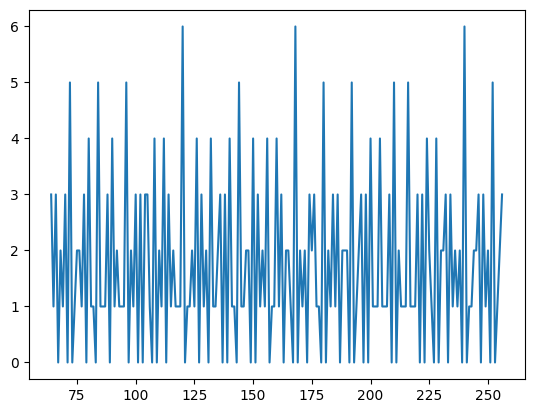

In [5]:
d_model = [i for i in range(64, 257)]
p = [i for i in range(2, 9)]

t = []
for j in d_model:
    count = 0
    for i in p:
        if j % i == 0:
            count += 1
    t.append(count)

import matplotlib.pyplot as plt

plt.plot(d_model, t)